<div style="display: flex; justify-content: center;">
  <img src="image.png"
       style="width: 100%; height: auto; border-radius:10px; background-color:#f0f0f0;">
</div>

<h1 style="background-color:#7A111C; color:#039C10; text-align:center; padding:10px; border-radius:8px;font-family: Georgia, serif;">
    <b>Analysis And Prediction Of Customer Churn</b>
</h1>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\GCE\Desktop\resume_rinshad\New Folder\customer_churn_dataset_1000_rows.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [3]:
df=df.drop(['CustomerID'],axis=1)

In [4]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
df.shape

(1000, 11)

In [6]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [7]:
df.Churn.unique()

array([1, 0])

In [8]:
df.describe(include='object')

,Gender,Subscription Type,Contract Length
count,1000,1000,1000
unique,2,3,3
top,Male,Premium,Annual
freq,514,350,353


In [9]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.501000,31.651000,15.340000,4.784000,15.111000,566.609000,14.954000,0.242000
std,13.875681,17.376511,8.874523,3.122674,8.948338,257.534242,8.689614,0.428509
min,18.000000,1.000000,1.000000,0.000000,0.000000,101.000000,1.000000,0.000000
25%,29.000000,17.000000,8.000000,2.000000,7.000000,344.000000,7.000000,0.000000
50%,42.000000,33.000000,15.000000,5.000000,15.000000,573.500000,15.000000,0.000000
75%,54.000000,46.000000,24.000000,8.000000,23.000000,795.250000,22.250000,0.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Gender             1000 non-null   object
 2   Tenure             1000 non-null   int64 
 3   Usage Frequency    1000 non-null   int64 
 4   Support Calls      1000 non-null   int64 
 5   Payment Delay      1000 non-null   int64 
 6   Subscription Type  1000 non-null   object
 7   Contract Length    1000 non-null   object
 8   Total Spend        1000 non-null   int64 
 9   Last Interaction   1000 non-null   int64 
 10  Churn              1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [11]:
df.groupby("Gender")[["Churn","Total Spend"]].mean()

,Churn,Total Spend
Gender,,
Female,0.318930,568.915638
Male,0.169261,564.428016


In [12]:
df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [13]:
datadict=pd.DataFrame(df.dtypes)
datadict['MissingVal'] =df.isnull().sum()
datadict['NUnique']=df.nunique()
datadict['Count']=df.count()
datadict = datadict.rename(columns={0:'DataType'})
datadict


,DataType,MissingVal,NUnique,Count
Age,int64,0,48,1000
Gender,object,0,2,1000
Tenure,int64,0,60,1000
Usage Frequency,int64,0,30,1000
Support Calls,int64,0,11,1000
Payment Delay,int64,0,31,1000
Subscription Type,object,0,3,1000
Contract Length,object,0,3,1000
Total Spend,int64,0,594,1000
Last Interaction,int64,0,30,1000


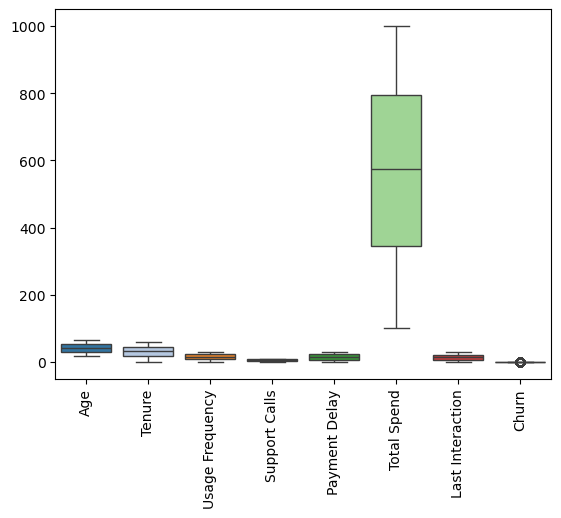

In [14]:
sns.boxplot(data=df, palette="tab20")
plt.xticks(rotation=90)
plt.xticks(rotation=90);

Subscription Type
Premium     0.350
Basic       0.328
Standard    0.322
Name: proportion, dtype: float64

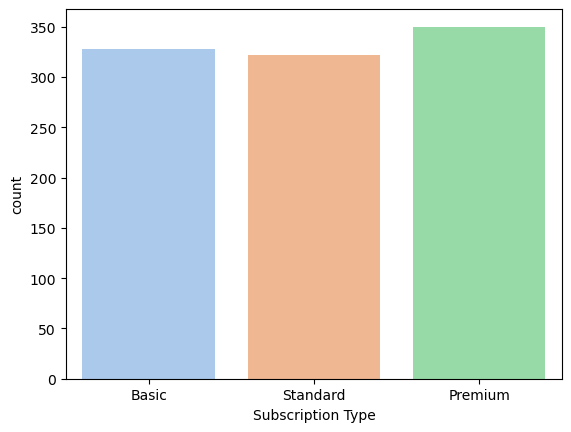

In [15]:
sns.countplot(data=df, x='Subscription Type', palette='pastel')
df['Subscription Type'].value_counts(normalize=True)

<Axes: ylabel='Total Spend'>

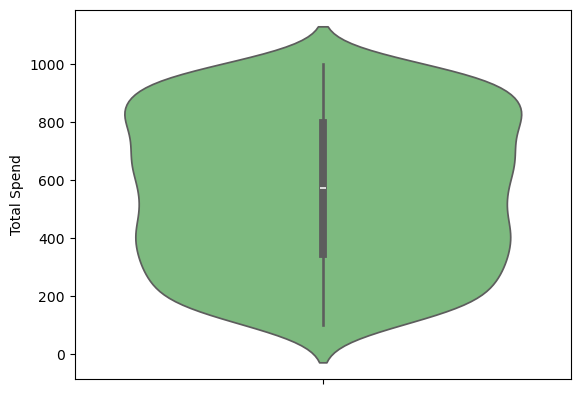

In [16]:
sns.violinplot(data=df, y='Total Spend', palette='Greens')



“This violin plot shows the distribution and density of total customer spending.”

<Axes: xlabel='Support Calls', ylabel='Count'>

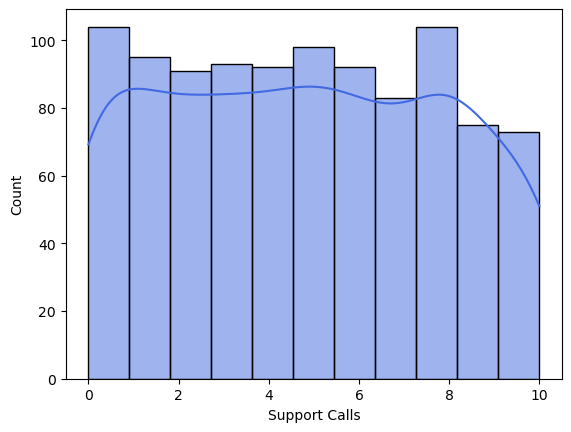

In [17]:
sns.histplot(df["Support Calls"], kde=True, color='royalblue')

This histogram visualizes the distribution of customer support calls, highlighting how frequently customers contact support and the overall density pattern.”

<Axes: xlabel='Age', ylabel='Density'>

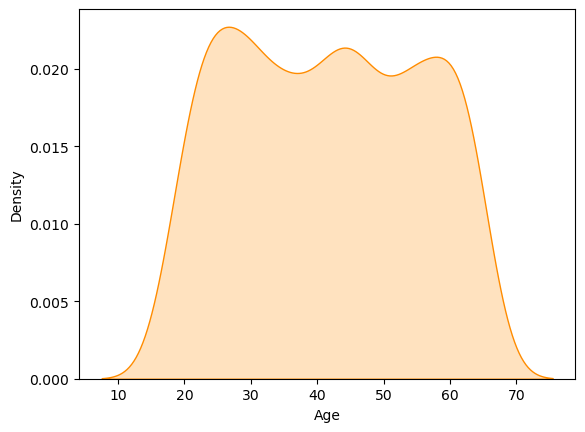

In [18]:
sns.kdeplot(df["Age"],fill=True,color="darkorange")

This KDE plot shows how the distribution of customer ages is spread across different values.

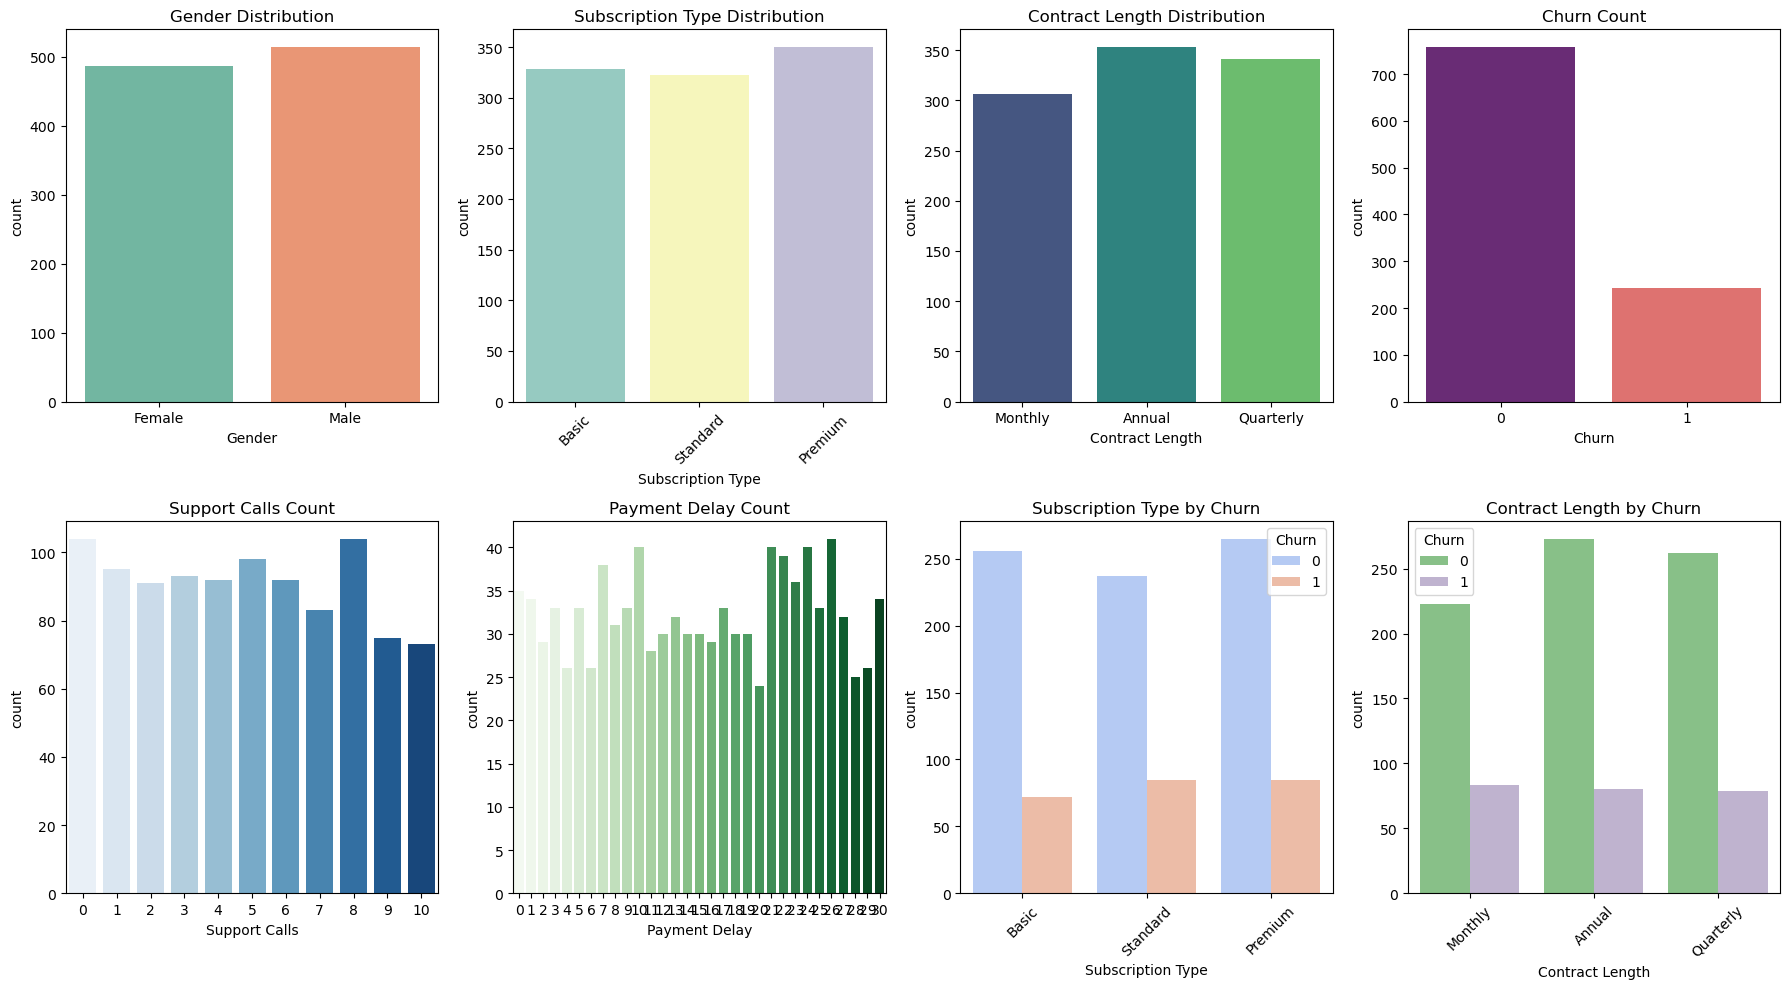

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
sns.countplot(x='Gender', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title("Gender Distribution")
sns.countplot(x='Subscription Type', data=df, ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title("Subscription Type Distribution")
axes[0, 1].tick_params(axis='x', rotation=45)
sns.countplot(x='Contract Length', data=df, ax=axes[0, 2], palette='viridis')
axes[0, 2].set_title("Contract Length Distribution")
sns.countplot(x='Churn', data=df, ax=axes[0, 3], palette='magma')
axes[0, 3].set_title("Churn Count")
sns.countplot(x='Support Calls', data=df, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title("Support Calls Count")
sns.countplot(x='Payment Delay', data=df, ax=axes[1, 1], palette='Greens')
axes[1, 1].set_title("Payment Delay Count")
sns.countplot(x='Subscription Type', data=df, hue='Churn', ax=axes[1, 2], palette='coolwarm')
axes[1, 2].set_title("Subscription Type by Churn")
axes[1, 2].tick_params(axis='x', rotation=45)
sns.countplot(x='Contract Length', data=df, hue='Churn', ax=axes[1, 3], palette='Accent')
axes[1, 3].set_title("Contract Length by Churn")
axes[1, 3].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


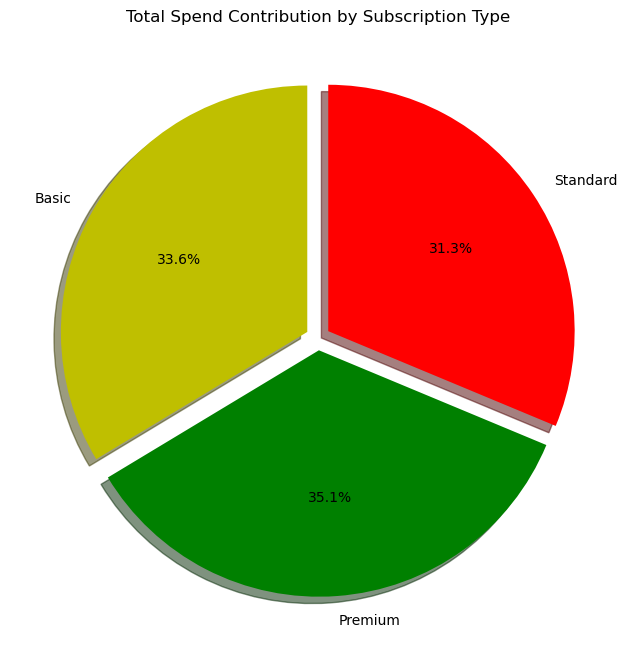

In [20]:
spend_by_subscription = df.groupby('Subscription Type')['Total Spend'].sum()

plt.figure(figsize=(8, 8))
colors = ['y', 'g', 'r']

plt.pie(
    spend_by_subscription,
    labels=spend_by_subscription.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05] * len(spend_by_subscription),
    shadow=True,
    colors=colors
)

plt.title("Total Spend Contribution by Subscription Type")
plt.show()


 This set of plots helps us understand the distribution of customer demographics, subscription types, contract lengths, churn status, and usage-related behaviors.

<Axes: xlabel='Subscription Type', ylabel='Total Spend'>

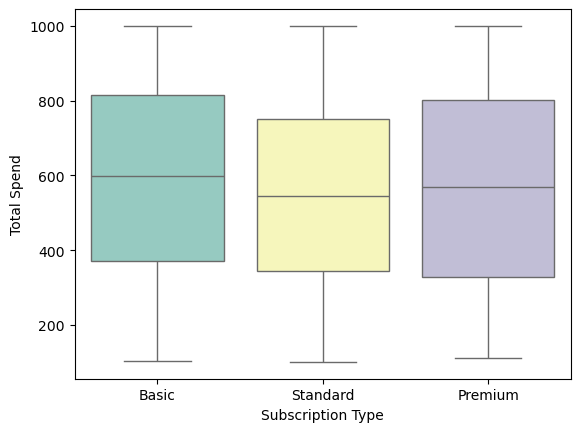

In [21]:
sns.boxplot(data=df, x='Subscription Type', y='Total Spend', palette='Set3')


This plot shows the distribution of total customer spending across different subscription types and highlights which subscription types generate higher spending.

<Axes: xlabel='Support Calls', ylabel='Payment Delay'>

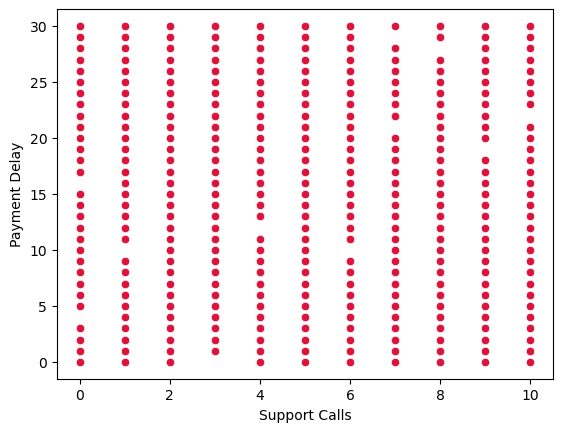

In [22]:
 sns.scatterplot(x='Support Calls', y='Payment Delay', data=df, color='crimson')

It visualizes whether customers who make more support calls also tend to experience higher payment delays.

([0, 1, 2],
 [Text(0, 0, 'Monthly'), Text(1, 0, 'Annual'), Text(2, 0, 'Quarterly')])

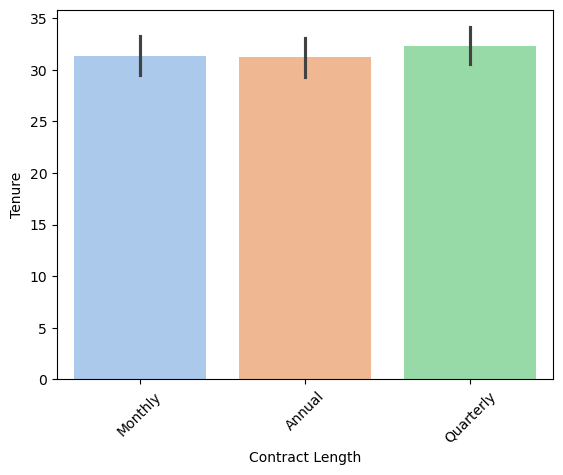

In [23]:
sns.barplot(data=df, x='Contract Length', y='Tenure', palette='pastel')
plt.xticks(rotation=45)

This bar plot illustrates the average customer tenure across different contract lengths, highlighting how contract duration relates to customer retention.

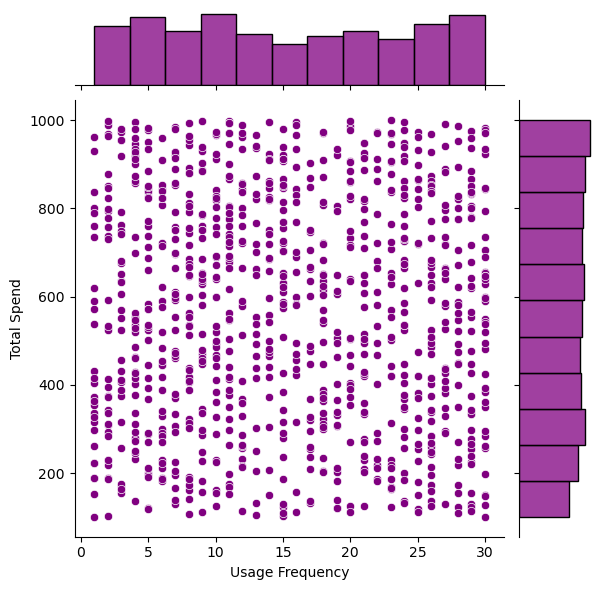

In [24]:
sns.jointplot(data=df, x='Usage Frequency', y='Total Spend', color='purple')




This joint plot visualizes the relationship between customer usage frequency and total spending, along with the distribution of each variable.

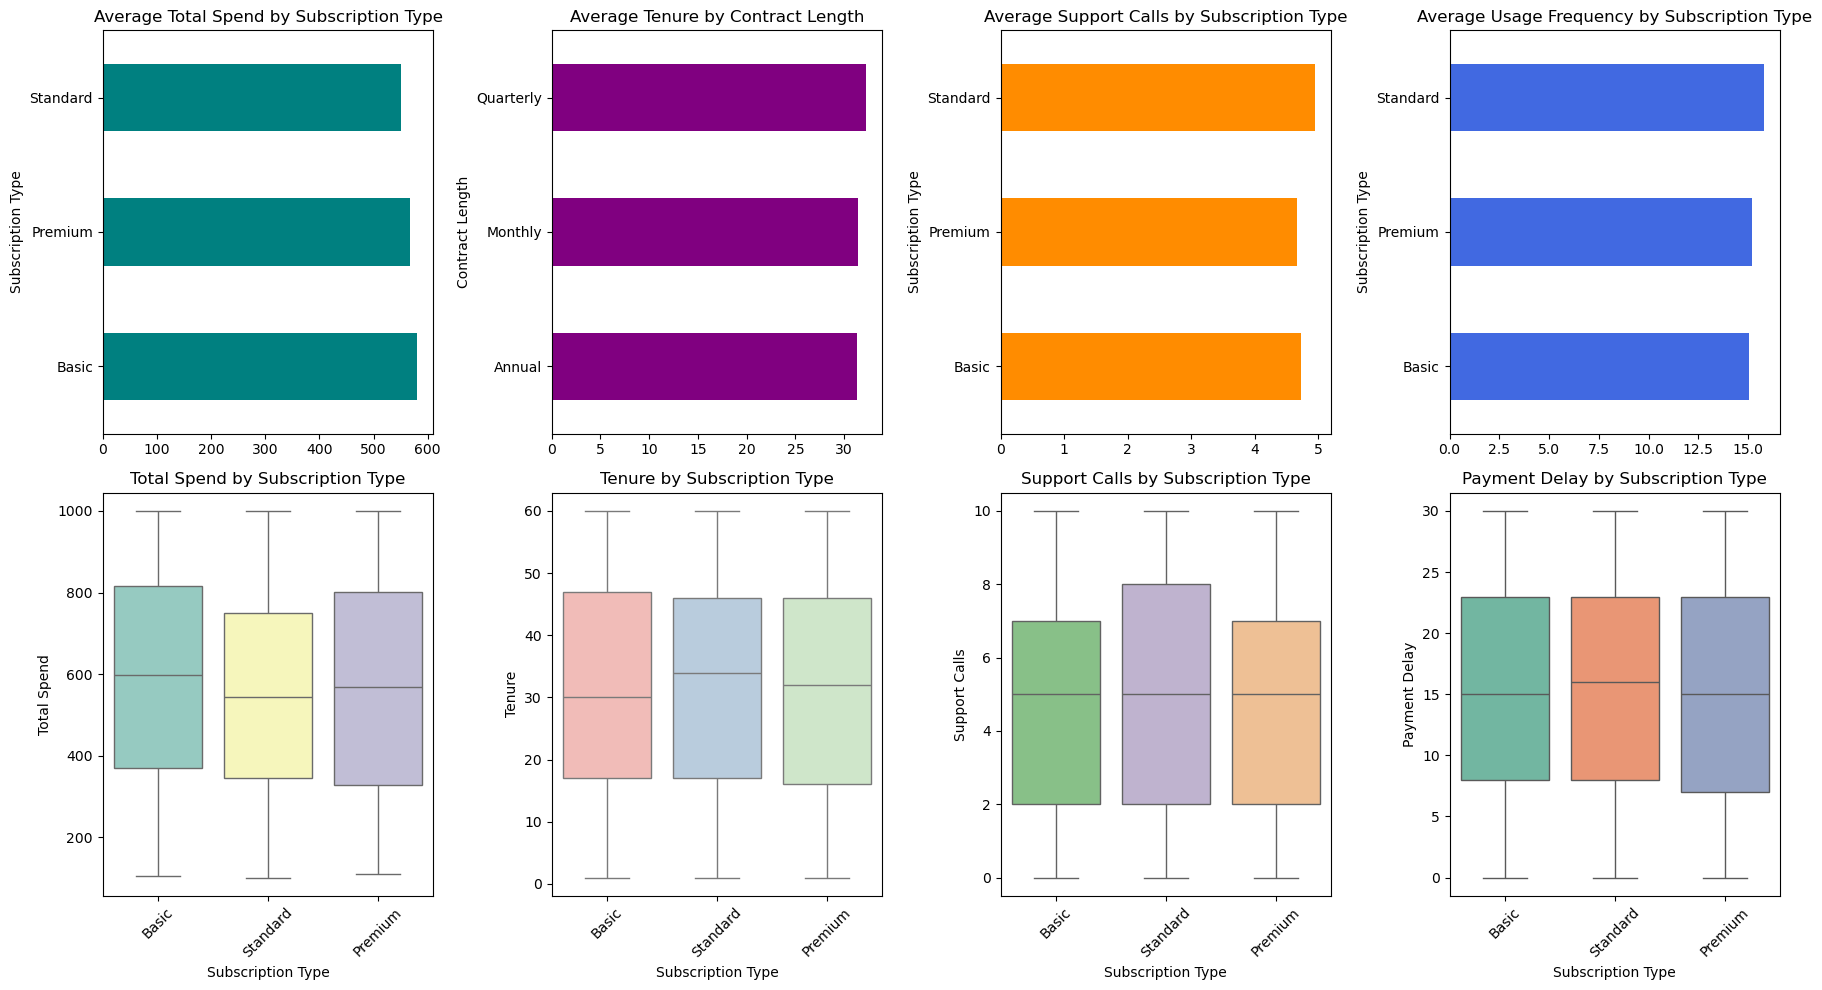

In [25]:
figbi, axesbi = plt.subplots(2, 4, figsize=(18, 10))
df.groupby('Subscription Type')['Total Spend'].mean().plot(
    kind='barh', ax=axesbi[0, 0], color='teal')
axesbi[0, 0].set_title("Average Total Spend by Subscription Type")
df.groupby('Contract Length')['Tenure'].mean().plot(
    kind='barh', ax=axesbi[0, 1], color='purple')
axesbi[0, 1].set_title("Average Tenure by Contract Length")
df.groupby('Subscription Type')['Support Calls'].mean().plot(
    kind='barh', ax=axesbi[0, 2], color='darkorange')
axesbi[0, 2].set_title("Average Support Calls by Subscription Type")
df.groupby('Subscription Type')['Usage Frequency'].mean().plot(
    kind='barh', ax=axesbi[0, 3], color='royalblue')
axesbi[0, 3].set_title("Average Usage Frequency by Subscription Type")
sns.boxplot(
    x="Subscription Type", y="Total Spend",
    data=df, ax=axesbi[1, 0], palette='Set3')
axesbi[1, 0].set_title("Total Spend by Subscription Type")
axesbi[1, 0].tick_params(axis='x', rotation=45)
sns.boxplot(
    x="Subscription Type", y="Tenure",
    data=df, ax=axesbi[1, 1], palette='Pastel1')
axesbi[1, 1].set_title("Tenure by Subscription Type")
axesbi[1, 1].tick_params(axis='x', rotation=45)
sns.boxplot(
    x="Subscription Type", y="Support Calls",
    data=df, ax=axesbi[1, 2], palette='Accent')
axesbi[1, 2].set_title("Support Calls by Subscription Type")
axesbi[1, 2].tick_params(axis='x', rotation=45)
sns.boxplot(
    x="Subscription Type", y="Payment Delay",
    data=df, ax=axesbi[1, 3], palette='Set2')
axesbi[1, 3].set_title("Payment Delay by Subscription Type")
axesbi[1, 3].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

This set of plots compares average customer metrics and their distributions across subscription types and contract lengths, providing insights into spending, tenure, and service usage behavior.

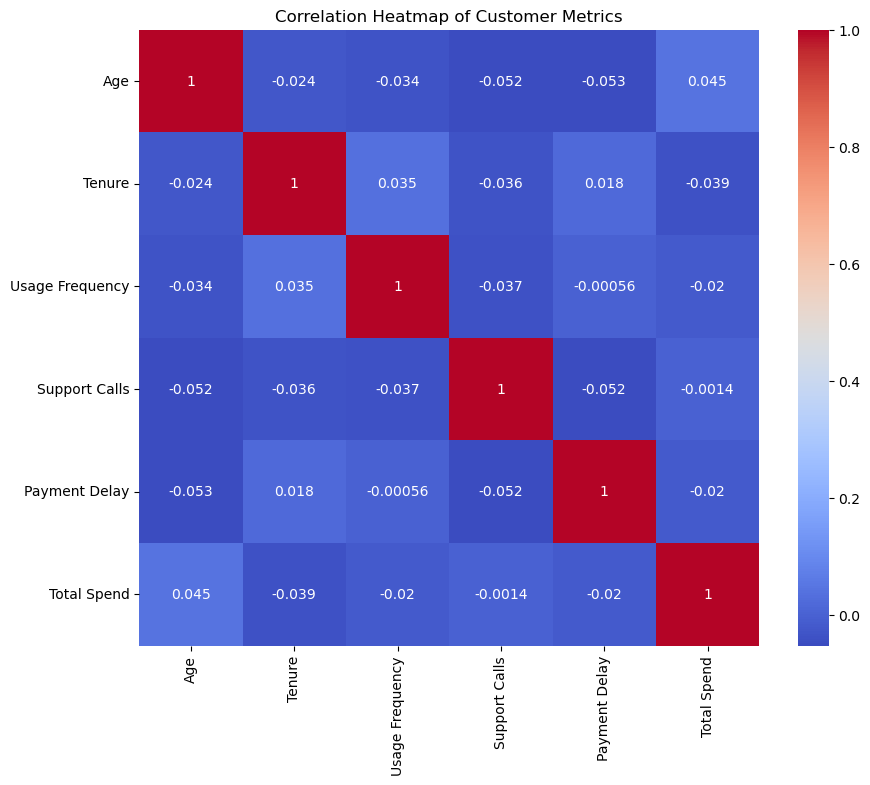

In [26]:
plt.figure(figsize=(10, 8))
col_num = df[['Age', 'Tenure', 'Usage Frequency',
     'Support Calls', 'Payment Delay', 'Total Spend']]
sns.heatmap(col_num.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Customer Metrics");

This correlation heatmap highlights the relationships among key numeric customer metrics, helping identify factors associated with customer behavior and spending.

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
le = LabelEncoder()
for col in ['Gender', 'Subscription Type', 'Contract Length', 'Churn']:
    df[col] = le.fit_transform(df[col])
df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...
995,32,1,39,26,8,20,1,1,344,3,1
996,29,1,37,26,3,26,0,0,159,28,0
997,51,0,33,5,6,5,2,2,850,6,1
998,56,1,34,6,2,26,0,0,271,28,0


Categorical variables in the dataset were encoded using label encoding to convert them into numerical form for analysis.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                1000 non-null   int64
 1   Gender             1000 non-null   int64
 2   Tenure             1000 non-null   int64
 3   Usage Frequency    1000 non-null   int64
 4   Support Calls      1000 non-null   int64
 5   Payment Delay      1000 non-null   int64
 6   Subscription Type  1000 non-null   int64
 7   Contract Length    1000 non-null   int64
 8   Total Spend        1000 non-null   int64
 9   Last Interaction   1000 non-null   int64
 10  Churn              1000 non-null   int64
dtypes: int64(11)
memory usage: 86.1 KB


In [30]:
df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...
995,32,1,39,26,8,20,1,1,344,3,1
996,29,1,37,26,3,26,0,0,159,28,0
997,51,0,33,5,6,5,2,2,850,6,1
998,56,1,34,6,2,26,0,0,271,28,0


In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()
num_cols = [
    'Age', 'Tenure', 'Usage Frequency',
    'Support Calls', 'Payment Delay', 'Total Spend'
]
df[num_cols] = scaler.fit_transform(df[num_cols])
df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,-1.406112,0,-0.382950,-0.151070,-0.251192,1.329291,0,1,0.121952,9,1
1,-0.036124,0,-0.210216,1.427269,0.710003,-0.236028,2,1,0.067563,20,0
2,0.396503,1,-0.267794,-0.602024,-0.891990,1.552908,1,0,0.739654,21,0
3,-0.468752,1,-1.304194,-0.376547,0.069206,0.211206,1,2,-1.299930,18,0
4,0.829131,0,1.517116,0.976315,1.350800,-1.465921,2,0,-0.130568,18,0
...,...,...,...,...,...,...,...,...,...,...,...
995,-0.685066,1,0.423139,1.201792,1.030402,0.546632,1,1,-0.864819,3,1
996,-0.901380,1,0.307983,1.201792,-0.571591,1.217483,0,0,-1.583529,28,0
997,0.684922,0,0.077672,-1.165716,0.389605,-1.130496,2,2,1.100952,6,1
998,1.045445,1,0.135250,-1.052978,-0.891990,1.217483,0,0,-1.148418,28,0


StandardScaler was applied to normalize numeric features by removing the mean and scaling to unit variance, improving comparability across variables.

In [33]:
x=df.drop("Churn",axis=1)
x

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,-1.406112,0,-0.382950,-0.151070,-0.251192,1.329291,0,1,0.121952,9
1,-0.036124,0,-0.210216,1.427269,0.710003,-0.236028,2,1,0.067563,20
2,0.396503,1,-0.267794,-0.602024,-0.891990,1.552908,1,0,0.739654,21
3,-0.468752,1,-1.304194,-0.376547,0.069206,0.211206,1,2,-1.299930,18
4,0.829131,0,1.517116,0.976315,1.350800,-1.465921,2,0,-0.130568,18
...,...,...,...,...,...,...,...,...,...,...
995,-0.685066,1,0.423139,1.201792,1.030402,0.546632,1,1,-0.864819,3
996,-0.901380,1,0.307983,1.201792,-0.571591,1.217483,0,0,-1.583529,28
997,0.684922,0,0.077672,-1.165716,0.389605,-1.130496,2,2,1.100952,6
998,1.045445,1,0.135250,-1.052978,-0.891990,1.217483,0,0,-1.148418,28


In [34]:
y=df["Churn"]
y

0      1
1      0
2      0
3      0
4      0
      ..
995    1
996    0
997    1
998    0
999    0
Name: Churn, Length: 1000, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
model=LogisticRegression()

In [39]:
model=model.fit(x_train,y_train)

In [40]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [41]:
from sklearn.metrics import accuracy_score

In [42]:
accuracy=accuracy_score(y_test,y_pred)

In [45]:
accuracy *100

86.0

In [51]:
from sklearn.ensemble import RandomForestClassifier
model2=RandomForestClassifier(n_estimators=100, random_state=42)

In [52]:
moodel2=model2.fit(x_train,y_train)

In [54]:
y_pred2=model2.predict(x_test)
y_pred2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
accuracy2=accuracy_score(y_test,y_pred2)
